In [49]:
%pip uninstall -y pyfolio
%pip install -U pip setuptools wheel
%pip install pyfolio-reloaded

In [50]:
from pandas.tseries.offsets import BDay
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from tqdm import tqdm
try:
    import pyfolio as pf
except ImportError:
    import pyfolio_reloaded as pf


/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


## Using ML for Portfolio Factors Strategy

From a pool of stocks, we run XGBoost regression on a backtest window with start and end dates.

In [51]:
# ----------------------------
# 1. Parameters
# ----------------------------
tickers = [
    "AAPL","MSFT","GOOG","AMZN","TSLA",
    "META","NVDA","NFLX","AMD","INTC",
    "JPM","BAC","WFC","GS","MS",
    "XOM","CVX","JNJ","PFE","UNH",
    "KO","PEP","MCD","WMT","COST",
    "HD","LOW","DIS","CRM","ORCL"
]

start_date = "2016-01-01"
end_date = "2025-12-01"



In [52]:
# feature / label windows
prediction_horizon = 20
train_window = 504  # 2 years to reduce noise
transaction_cost = 0.001

# universe filter
min_coverage_ratio = 0.90
min_required_obs = train_window + prediction_horizon + 180

# portfolio construction
top_n = 8
signal_quantile = 0.75      # only trade strongest signals
max_name_weight = 0.15      # cap single-name concentration
market_ma_window = 200      # risk filter
use_long_only = True        # reduce drawdown from weak short leg

In [53]:
# ----------------------------
# 2. Download price + volume
# ----------------------------
raw = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"].copy()
    volume = raw["Volume"].copy()
else:
    close = raw[["Close"]].copy()
    close.columns = tickers[:1]
    volume = raw[["Volume"]].copy()
    volume.columns = tickers[:1]

coverage_ratio = close.notna().mean()
obs_count = close.notna().sum()
eligible_tickers = coverage_ratio[
    (coverage_ratio >= min_coverage_ratio) &
    (obs_count >= min_required_obs)
].index.tolist()

prices = close[eligible_tickers].copy().dropna(how="all")
volume = volume[eligible_tickers].copy().reindex(prices.index)
tickers = prices.columns.tolist()

returns = prices.pct_change()

spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy_close = spy["Close"].squeeze()
else:
    spy_close = spy["Close"].copy()

benchmark = spy_close.pct_change().reindex(prices.index)
market_filter = (spy_close > spy_close.rolling(market_ma_window).mean()).astype(float).reindex(prices.index).fillna(0.0)

print("Number of selected stocks:", len(tickers))
print("Selected tickers:", tickers)

if len(tickers) == 0:
    raise ValueError(
        "No stocks passed the universe filter. "
        "Relax min_coverage_ratio or min_required_obs."
    )


Number of selected stocks: 30
Selected tickers: ['AAPL', 'AMD', 'AMZN', 'BAC', 'COST', 'CRM', 'CVX', 'DIS', 'GOOG', 'GS', 'HD', 'INTC', 'JNJ', 'JPM', 'KO', 'LOW', 'MCD', 'META', 'MS', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PFE', 'TSLA', 'UNH', 'WFC', 'WMT', 'XOM']


Compute the features - momentum and volatility to use as predictors. These are very elementary for now. The predictors need to be changed here.

In [54]:
# ----------------------------
# 3. Compute richer features and pooled panel dataset
# FIXED VERSION FOR EMPTY PANEL
# ----------------------------

daily_ret = prices.pct_change()

# price-based features
mom_20 = prices.pct_change(20).shift(1)
mom_60 = prices.pct_change(60).shift(1)
mom_120 = prices.pct_change(120).shift(1)
rev_5 = prices.pct_change(5).shift(1)

vol_20 = daily_ret.rolling(20).std().shift(1)
vol_60 = daily_ret.rolling(60).std().shift(1)

# FIX:
# 不要用 where(<0) 直接制造大量 NaN
# 用 clip(upper=0) 保留负收益，把正收益设为 0
downside_ret = daily_ret.clip(upper=0)
downside_vol_20 = downside_ret.rolling(20, min_periods=10).std().shift(1)

ma_20 = prices.rolling(20).mean().shift(1)
ma_60 = prices.rolling(60).mean().shift(1)
ma_gap_20_60 = (ma_20 / ma_60 - 1.0)

# liquidity feature
avg_dollar_vol_20 = (prices * volume).rolling(20).mean().shift(1)
log_dollar_vol = np.log(avg_dollar_vol_20.replace(0, np.nan))
liquidity_z = (
    (log_dollar_vol - log_dollar_vol.rolling(60).mean().shift(1)) /
    (log_dollar_vol.rolling(60).std().shift(1) + 1e-8)
)

# future return target
future_returns = prices.pct_change(prediction_horizon).shift(-prediction_horizon)

feature_cols = [
    "mom_20", "mom_60", "mom_120", "rev_5",
    "vol_20", "vol_60", "downside_vol_20",
    "ma_gap_20_60", "liquidity_z"
]

# build pooled panel
panel_frames = []
for ticker in tickers:
    df = pd.DataFrame({
        "date": prices.index,
        "ticker": ticker,
        "mom_20": mom_20[ticker],
        "mom_60": mom_60[ticker],
        "mom_120": mom_120[ticker],
        "rev_5": rev_5[ticker],
        "vol_20": vol_20[ticker],
        "vol_60": vol_60[ticker],
        "downside_vol_20": downside_vol_20[ticker],
        "ma_gap_20_60": ma_gap_20_60[ticker],
        "liquidity_z": liquidity_z[ticker],
        "target_raw": future_returns[ticker],
    })
    panel_frames.append(df)

panel = pd.concat(panel_frames, ignore_index=True)
panel = panel.replace([np.inf, -np.inf], np.nan)
panel["date"] = pd.to_datetime(panel["date"]).dt.normalize()

# risk-adjusted target
panel["target_risk_adj"] = panel["target_raw"] / (panel["vol_20"] * np.sqrt(prediction_horizon) + 1e-8)

# cross-sectional standardisation
grp = panel.groupby("date")["target_risk_adj"]
panel["target"] = ((panel["target_risk_adj"] - grp.transform("mean")) /
                   (grp.transform("std") + 1e-8)).clip(-3, 3)

# 先只对核心列做严格过滤
required_cols = [
    "mom_20", "mom_60", "mom_120", "rev_5",
    "vol_20", "vol_60",
    "ma_gap_20_60", "liquidity_z",
    "target"
]
panel = panel.dropna(subset=required_cols).copy()

# downside_vol_20 再单独填补
panel["downside_vol_20"] = panel.groupby("date")["downside_vol_20"].transform(
    lambda s: s.fillna(s.median())
)
panel["downside_vol_20"] = panel["downside_vol_20"].fillna(0.0)

print("Panel rows:", len(panel))
print("Panel unique dates:", panel["date"].nunique())
print("Panel unique tickers:", panel["ticker"].nunique())
print("Panel date range:", panel["date"].min(), "to", panel["date"].max())

if panel.empty:
    raise ValueError("Panel is still empty after feature engineering. Check prices/volume download.")

# 直接从 panel 生成每月最后一个可交易日
panel_dates = pd.DatetimeIndex(sorted(panel["date"].unique()))
rebalance_dates = (
    pd.Series(panel_dates, index=panel_dates.to_period("M"))
    .groupby(level=0)
    .max()
    .tolist()
)

print("Number of rebalance dates:", len(rebalance_dates))
print("First 5 rebalance dates:", rebalance_dates[:5])
print("Last 5 rebalance dates:", rebalance_dates[-5:])

Panel rows: 70530
Panel unique dates: 2351
Panel unique tickers: 30
Panel date range: 2016-06-27 00:00:00 to 2025-10-30 00:00:00
Number of rebalance dates: 113
First 5 rebalance dates: [Timestamp('2016-06-30 00:00:00'), Timestamp('2016-07-29 00:00:00'), Timestamp('2016-08-31 00:00:00'), Timestamp('2016-09-30 00:00:00'), Timestamp('2016-10-31 00:00:00')]
Last 5 rebalance dates: [Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-08-29 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-30 00:00:00')]


In [55]:
# ----------------------------
# 4. Rolling pooled ML prediction
# ROBUST VERSION
# ----------------------------

print("Final rebalance date count before backtest:", len(rebalance_dates))

pred_rows = []
debug_counter = 0

for date in tqdm(rebalance_dates, desc="Monthly pooled ML backtest"):
    train_end = pd.Timestamp(date) - BDay(prediction_horizon + 1)
    train_start = train_end - pd.Timedelta(days=train_window)

    train_df = panel[(panel["date"] >= train_start.normalize()) & (panel["date"] <= train_end.normalize())].copy()
    test_df = panel[panel["date"] == pd.Timestamp(date).normalize()].copy()

    if debug_counter < 5:
        print(f"\nDate: {date}")
        print("train rows:", len(train_df))
        print("test rows:", len(test_df))
        print("test tickers:", test_df["ticker"].nunique())
        debug_counter += 1

    # 放宽阈值，避免全部被跳过
    if len(train_df) < 300:
        continue

    if test_df["ticker"].nunique() < 3:
        continue

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(train_df[feature_cols], train_df["target"])

    test_df = test_df.copy()
    test_df["score"] = model.predict(test_df[feature_cols])

    pred_rows.append(test_df[["date", "ticker", "score", "vol_20"]])

if len(pred_rows) == 0:
    raise ValueError(
        "No prediction rows were generated. "
        "Look at the debug printouts above: train rows, test rows, and rebalance date count."
    )

pred_df = pd.concat(pred_rows, ignore_index=True)

predicted_signal = pred_df.pivot(index="date", columns="ticker", values="score").sort_index()
vol_for_weights = pred_df.pivot(index="date", columns="ticker", values="vol_20").sort_index()

print("Prediction rows:", len(pred_df))
print("Prediction dates:", predicted_signal.shape[0])
print("Prediction tickers:", predicted_signal.shape[1])


Final rebalance date count before backtest: 113


Monthly pooled ML backtest:   0%|          | 0/113 [00:00<?, ?it/s]


Date: 2016-06-30 00:00:00
train rows: 0
test rows: 30
test tickers: 30

Date: 2016-07-29 00:00:00
train rows: 120
test rows: 30
test tickers: 30

Date: 2016-08-31 00:00:00
train rows: 780
test rows: 30
test tickers: 30


Monthly pooled ML backtest:   3%|▎         | 3/113 [00:01<00:41,  2.64it/s]


Date: 2016-09-30 00:00:00
train rows: 1440
test rows: 30
test tickers: 30


Monthly pooled ML backtest:   4%|▎         | 4/113 [00:01<00:48,  2.26it/s]


Date: 2016-10-31 00:00:00
train rows: 2040
test rows: 30
test tickers: 30


Monthly pooled ML backtest: 100%|██████████| 113/113 [00:33<00:00,  3.39it/s]

Prediction rows: 3330
Prediction dates: 111
Prediction tickers: 30


In [56]:
# ----------------------------
# 5. Portfolio construction
# Long-only + confidence filter + inverse-vol weighting + market regime filter
# ----------------------------
weights = pd.DataFrame(0.0, index=predicted_signal.index, columns=predicted_signal.columns)

for date in predicted_signal.index:
    scores = predicted_signal.loc[date].dropna()
    if scores.empty:
        continue

    # only trade strongest names
    score_cutoff = scores.quantile(signal_quantile)
    longs = scores[scores >= score_cutoff].sort_values(ascending=False).head(top_n).index.tolist()

    if len(longs) == 0:
        continue

    inv_vol = 1.0 / vol_for_weights.loc[date, longs].replace(0, np.nan).dropna()
    if inv_vol.empty:
        continue

    w = inv_vol / inv_vol.sum()
    w = w.clip(upper=max_name_weight)
    w = w / w.sum()  # renormalize after cap

    weights.loc[date, w.index] = w.values

# move from rebalance dates to daily holdings and execute next day
weights = weights.reindex(prices.index).ffill().shift(1).fillna(0.0)

# market regime filter: stay in cash when SPY is below its 200-day MA
weights = weights.mul(market_filter, axis=0)

### Rationale of the backtest restuls
- On date of test, use the XGBoost model to find the relationship between the factors and the projected future return known on hindsight (for each stock).
- Sort the predicted return. Long the highest value and short the lowest value at the end of the month.
- At the next month, do the same and re-adjust the portfolio based on the long/short stocks.
![Backtest_Factors.png](attachment:ba29190d-289e-4fa3-b5d7-81a1b94693ab.png)


In [57]:

# ----------------------------
# 6. Apply transaction costs
# ----------------------------
weight_change = weights.diff().abs().sum(axis=1)
daily_returns = (weights * returns.fillna(0.0)).sum(axis=1)
daily_returns = daily_returns - weight_change * transaction_cost

benchmark = benchmark.fillna(0.0)
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
benchmark = benchmark.reindex(daily_returns.index).fillna(0.0)


### Portfolio Backtest Results

Note the backtest results are based on daily returns, although rebalancing is done monthly. This means the returns are not all realised. (but unrealised)

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '24.662%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2016-01-04
End date,2025-11-28
Total months,118
,Backtest
Annual return,24.662%
Cumulative returns,784.497%
Annual volatility,13.798%
Sharpe ratio,1.67
Calmar ratio,1.65
Stability,0.97
Max drawdown,-14.961%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,14.96,2020-09-02,2020-09-23,2020-12-15,75
1,12.38,2023-07-28,2023-10-12,2023-12-13,99
2,11.62,2018-01-26,2018-04-02,2018-08-02,135
3,11.03,2025-01-23,2025-03-06,2025-08-08,142
4,9.93,2021-12-10,2022-01-25,2023-03-31,341


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
/usr/local/lib/python3.12/dist-packages/pyfolio/tears.py:1005: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


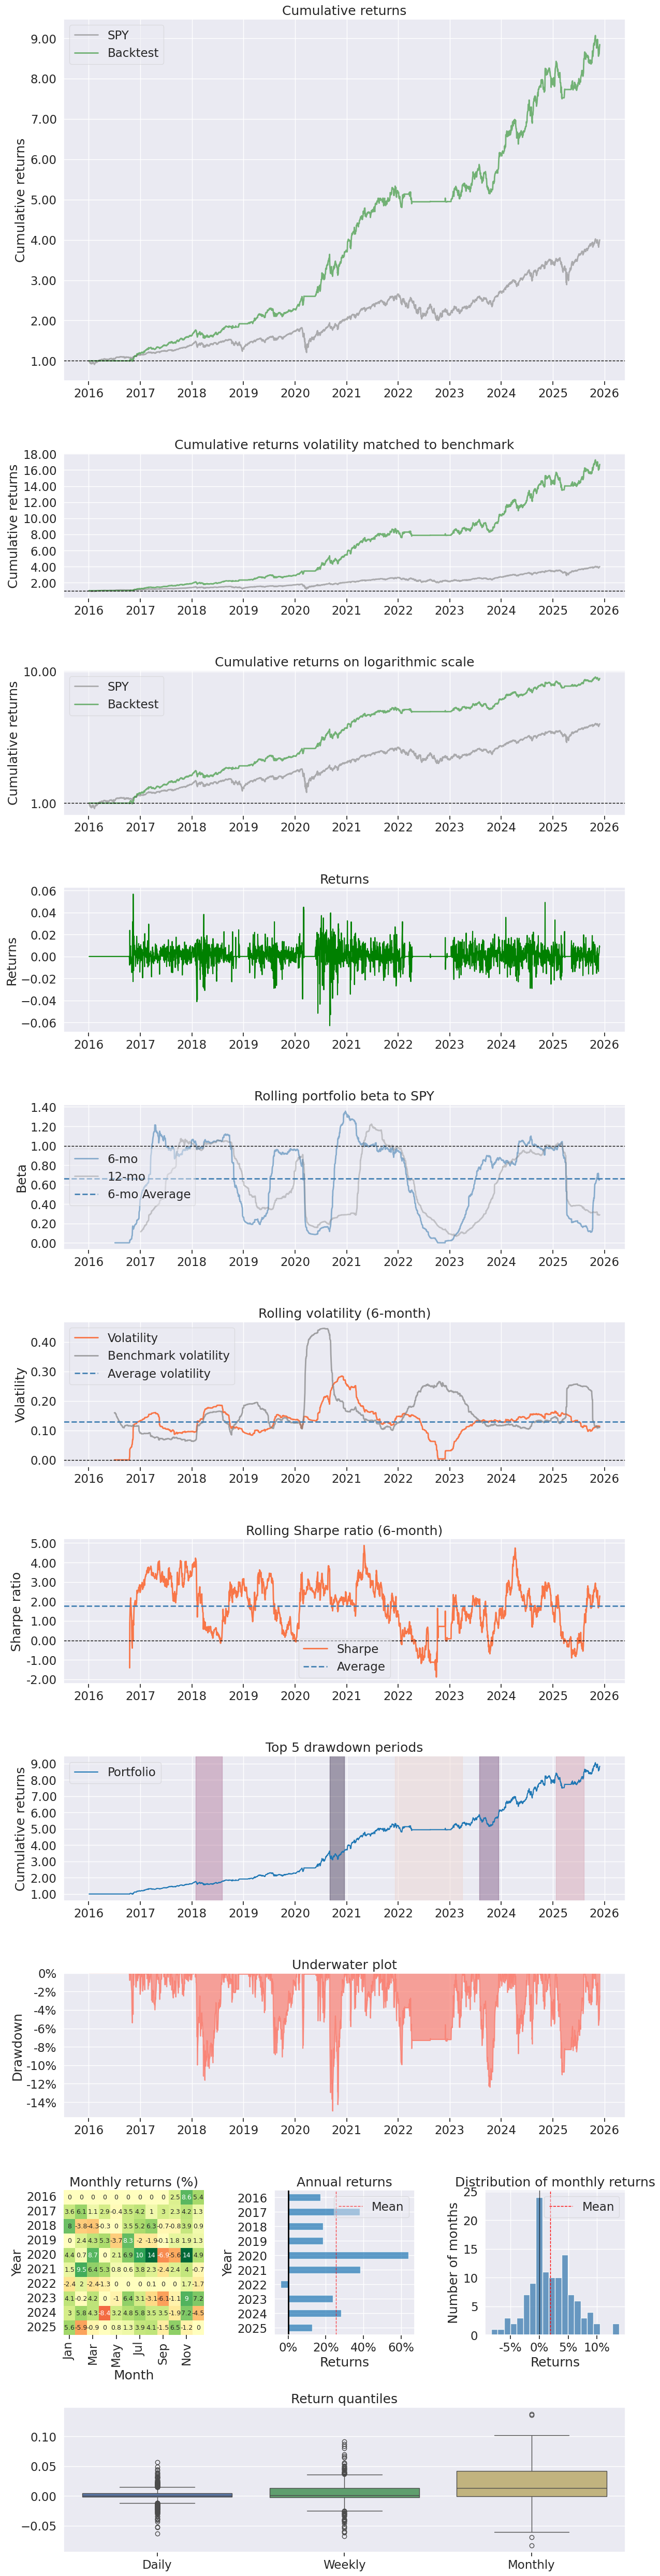

In [58]:
# ----------------------------
# 7. PyFolio analysis
# ----------------------------
# remove the initial 60 days lookback period
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
pf.create_full_tear_sheet(daily_returns.squeeze(), benchmark_rets=benchmark.squeeze())


### Comments on strategy
- The strategy outperformed the S\&P 500 index over the whole period. Although it must be noted that most of the gains occured in the year 2025.
- DUring the second half of 2024, the strategy did not do well, and fell almost 28% which took almost 4-5 months to recover.

### Exercise
- As part of the exercise, how will you improve the strategy?
    - Use more stocks
    - Do over a longer period of time for more robustness in results
    - Use another ML method.
    - Use a more stringent filter (with more stocks availability)
    - Use only long strategy (stocks) as a constraint.
    - Use other features (fundamentals eg) Note though these data available on a quarterly basis.
